# Fase 3. Visualización de datos

In [47]:
# Importamos librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer 

pd.set_option("display.max_columns", None)

Leemos el dataframe limpio para empezar las visualizaciones:

In [48]:
df_hr_limpios = pd.read_csv("clean-data/clean_df_hr.csv")

Leemos también los dataframes que tenemos separados con los trabajadores actuales y los que se han ido (los usaremos más adelante):

In [49]:
df_hr_quedan = pd.read_csv("clean-data/df_hr_attrition_no.csv")
df_hr_se_van = pd.read_csv("clean-data/df_hr_attrition_yes.csv")


In [50]:
df_hr_limpios['attrition_text'] = df_hr_limpios['attrition'].map({False: 'Se queda', True: 'Se va'})
df_hr_limpios.head(2)
# Hacemos un mapeo para cambiar los boleanos por una categoria definida (más fácil para interpretar los gráficos)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition_text
0,41,True,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,8,0,1,6,4,0,5,Se va
1,49,False,Travel_Frequently,Research & Development,8,1,Life Sciences,2,3,Male,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,10,3,3,10,7,1,7,Se queda


## 1. Contextualización de la empresa 'ABC Corporation'

In [51]:
print(f"""En total tenemos datos de {df_hr_limpios.shape[0]} empleados. 
En la tabla de abajo podemos ver cuántos siguen trabajando (attrition:False) y cuántos se han ido de la empresa (attrition: True).""")
df_hr_limpios['attrition'].value_counts()

En total tenemos datos de 1470 empleados. 
En la tabla de abajo podemos ver cuántos siguen trabajando (attrition:False) y cuántos se han ido de la empresa (attrition: True).


attrition
False    1233
True      237
Name: count, dtype: int64

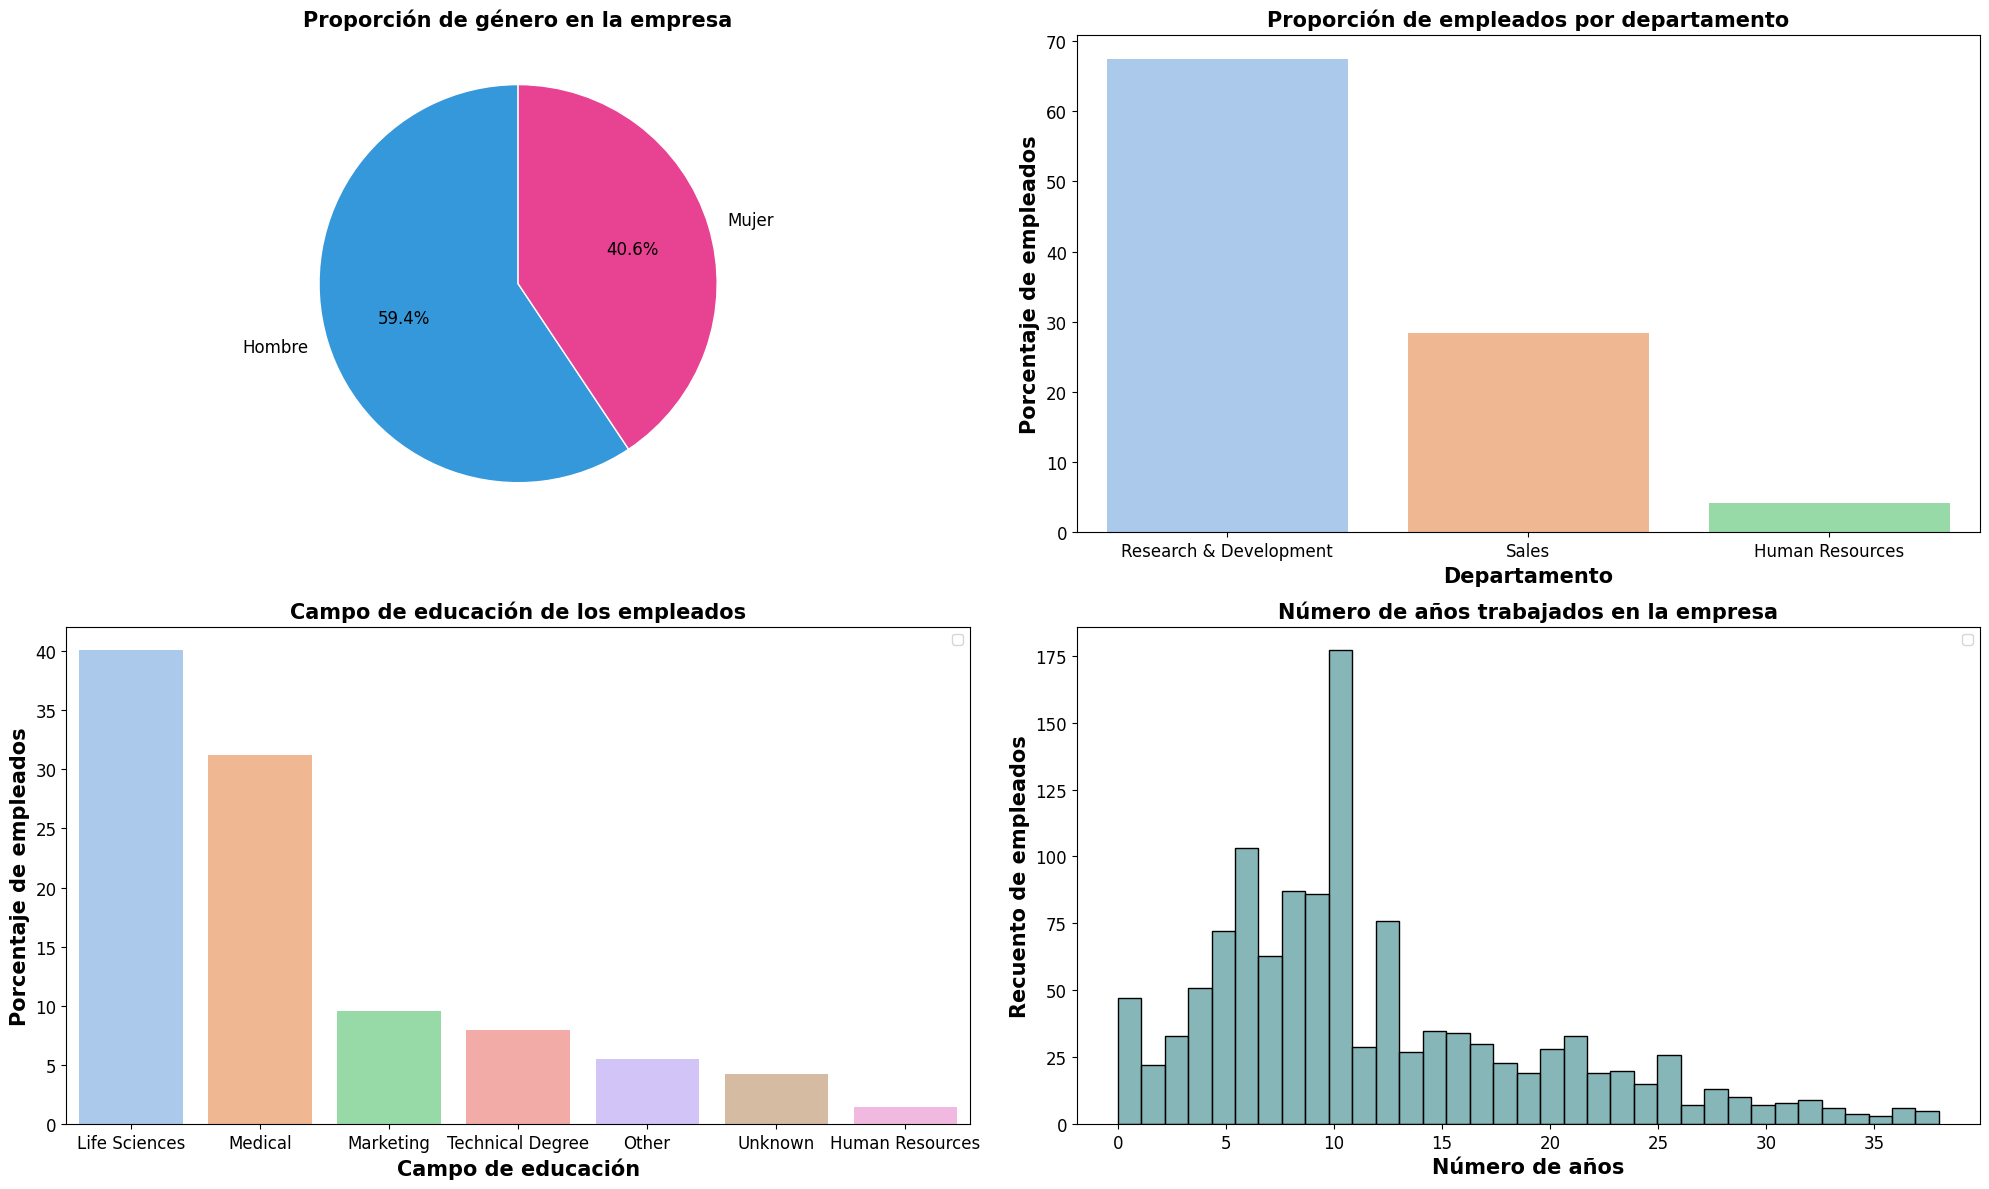

In [66]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))
# Pie del género de los empleados
conteo_genero = df_hr_quedan['gender'].value_counts()
labels = ['Hombre', 'Mujer']
axes[0,0].pie(conteo_genero,labels=labels,autopct='%1.1f%%',startangle=90, colors=['#3498db', '#e84393'],textprops={"fontsize": 12},wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[0,0].set_title("Proporción de género en la empresa",fontsize=15, fontweight='bold')

# Countplot con el porcentaje de trabajadores por departamento
dept_ordenados = df_hr_quedan["department"].value_counts().index
sns.countplot(data=df_hr_quedan, x='department',stat='percent',order=dept_ordenados, palette='pastel',ax=axes[0,1])
axes[0,1].set_title("Proporción de empleados por departamento",fontsize=15, fontweight='bold')
axes[0,1].set_xlabel("Departamento")
axes[0,1].set_ylabel("Porcentaje de empleados")

# Countplot con el campo de educación de los empleados
education_ordenada = df_hr_quedan["education_field"].value_counts().index
sns.countplot(data=df_hr_quedan, x='education_field',order=education_ordenada,stat='percent', palette='pastel',ax=axes[1,0])
axes[1,0].legend()
axes[1,0].set_title("Campo de educación de los empleados",fontsize=15, fontweight='bold')
axes[1,0].set_xlabel("Campo de educación")
axes[1,0].set_ylabel("Porcentaje de empleados")

# Histograma del número de años trabajados en la empresa
sns.histplot(data=df_hr_quedan, x="total_working_years",color='cadetblue',bins=35,ax=axes[1,1])
axes[1,1].legend()
axes[1,1].set_title("Número de años trabajados en la empresa",fontsize=15, fontweight='bold')
axes[1,1].set_xlabel("Número de años")
axes[1,1].set_ylabel("Recuento de empleados")

plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

plt.tight_layout();

Con estos gráficos queremos tener una visión general de la empresa para conocer mejor a nuestro cliente.
Con la información de qué educación tienen los empleados y el porcentaje de empleados en cada departamente, es bastante probable que estemos delante de una empresa farmacéutica o de dispositivos médicos. Claramente es una empresa técnica/científica. 
De echo, una sexta parte de los trabajadores de la empresa son hombres, lo cuál es bastante común en empresas más técnicas. Como comentario general: quizás la empresa podría tratar de reducir el gender gap entre sus empleados. 



## 2. Cuál es la rotación de empleados en la empresa?

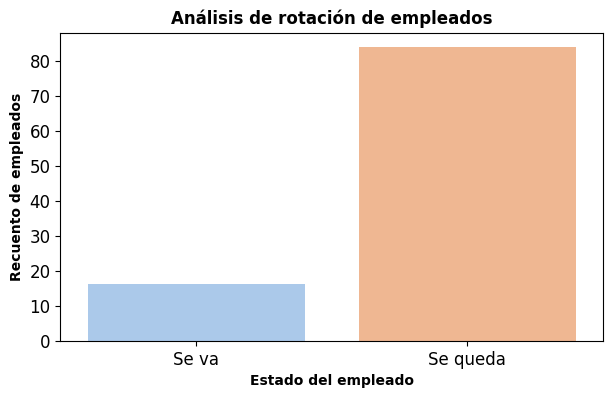

In [53]:
plt.figure(figsize=(7, 4))

sns.countplot(x='attrition_text', data=df_hr_limpios, stat='percent',palette='pastel')

plt.title('Análisis de rotación de empleados', fontsize=12, fontweight='bold')
plt.xlabel('Estado del empleado', fontsize=10)
plt.ylabel('Recuento de empleados', fontsize=10);

En este primer análisis observamos el recuento de empleados que siguen trabajando en la empresa, y los que se han ido. 
Aunque la mayoría de los empleados permanecen en la empresa (alrededor de un 80%), existe un grupo significativo que ha abandonado la organización. 
Esta visualización establece nuestra línea base: el objetivo del proyecto es identificar qué características comparten los empleados que abandonan la empresa para prevenir futuras salidas.


## 3. Cantidad de años trabajados según rotación 

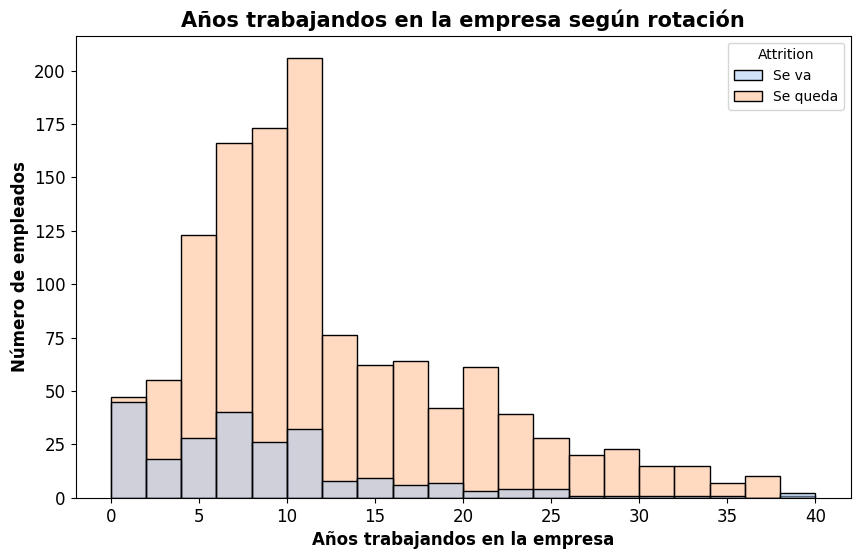

In [54]:
plt.figure(figsize=(10, 6))
ax=sns.histplot(data=df_hr_limpios, x = "total_working_years",hue="attrition_text",bins=20,palette="pastel")
plt.title('Años trabajandos en la empresa según rotación', fontsize=15,fontweight="bold")
plt.xlabel('Años trabajandos en la empresa', fontsize=12,fontweight="bold")
plt.ylabel('Número de empleados', fontsize=12,fontweight="bold")
sns.move_legend(ax, "upper right", title='Attrition');


La mayor concentración de empleados se encuentra entre los 5 y 10 años de antigüedad. Es el grupo más numeroso dentro de la empresa.
La gran mayoría de las renuncias o despidos ocurren en la primera década. Especialmente críticos son los primeros 2-3 años.
A partir de los 15 años de antigüedad hay una fase de estabilidad, lo que sugiere que una vez el empleado ha superado esta barrera, la probabilidad de que abandone la empresa es mucho menor.
La empresa debería enfocarse en programas de onboarding y fidelización para los empleados que llevan menos de 2 años, ya que es donde la fuga de talento es proporcionalmente más alta.

## 4. El factor "Dinero": Salario vs Rotación 

### 4.1. Con boxplot (más técnico):

In [55]:
media_ingreso_queda = round(df_hr_quedan["monthly_income"].mean(),2)
media_ingreso_se_van = round(df_hr_se_van["monthly_income"].mean(),2)
print(media_ingreso_queda)
print(media_ingreso_se_van)
# Medias como referencia por cada grupo, aunque se visualizan directamente el en gráfico con el parámetro "showmeans = True".

6815.33
4757.28


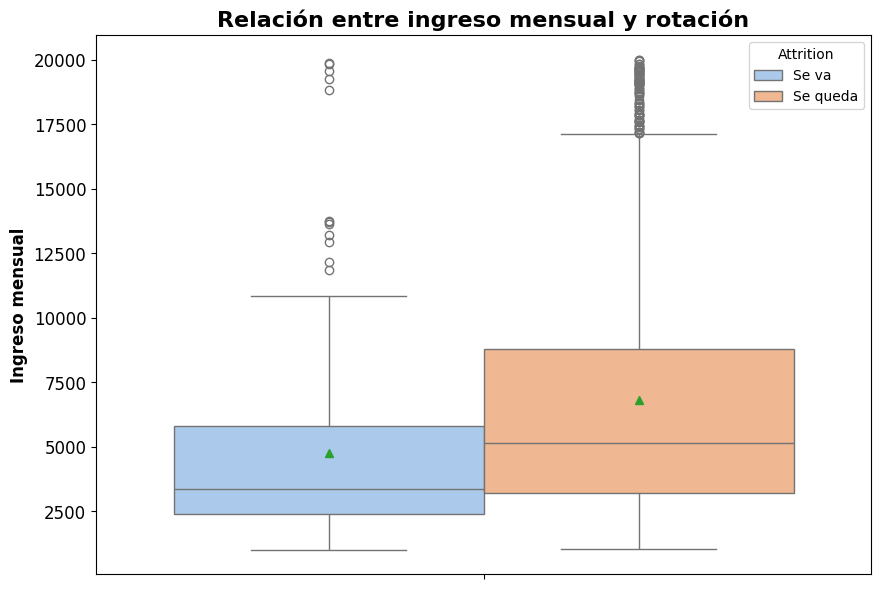

In [56]:
plt.figure(figsize=(10, 7))

sns.boxplot(data=df_hr_limpios, y='monthly_income', hue='attrition_text', showmeans=True, palette='pastel')
plt.title('Relación entre ingreso mensual y rotación', fontsize=16, fontweight='bold')
plt.ylabel('Ingreso mensual', fontsize=12)
plt.legend(title='Attrition');

Al comparar el ingreso mensual entre los empleados que permanecen en la empresa y los que se han ido vemos que hay una diferencia salarial.
La mayor parte de los empleados que se van tienen un salario que se concentra entre unos 5000 y 2500 (moneda sin especificar). De echo, el 75% de las personas que renunciaron, ganaban menos de 6000. 
La mediana salarial de quienes se van se sitúa por debajo del promedio de los que se quedan, lo que sugiere que la competitividad salarial es un factor crítico en la retención de talento de ABC Corporation, especialmente en los niveles de entrada. Una recomendación sería revisar si los sueldos son competitivos con el mercado.


### 4.2. Con histograma (más fácil de entender):

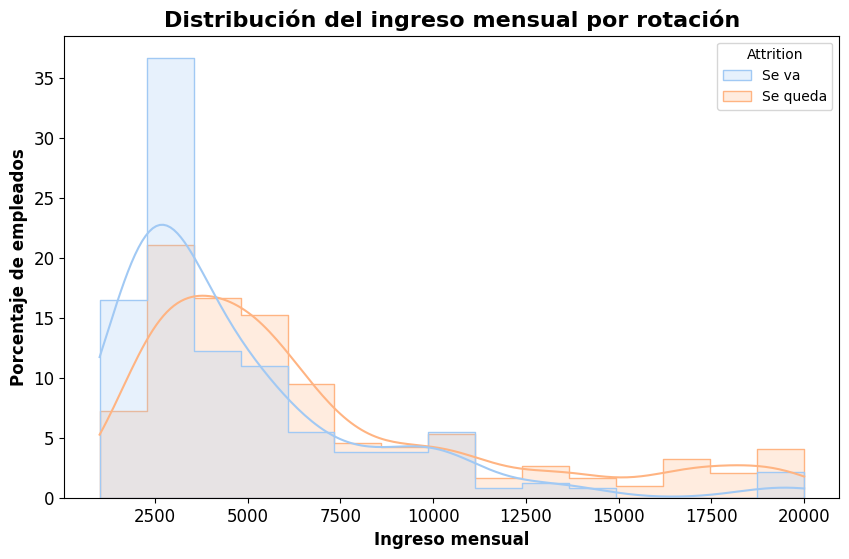

In [67]:
plt.figure(figsize=(10, 6))

ax= sns.histplot(data=df_hr_limpios, x='monthly_income', hue='attrition_text',bins=15, stat='percent', common_norm=False,kde=True, hue_order=['Se va', 'Se queda'],element="step", palette='pastel')

plt.title('Distribución del ingreso mensual por rotación', fontsize=16, fontweight='bold')
plt.xlabel('Ingreso mensual', fontsize=12)
plt.ylabel('Porcentaje de empleados', fontsize=12)
sns.move_legend(ax, "upper right", title='Attrition');

El análisis es parecido a con el boxplot, aunque con el histograma podemos ver la distribución del ingreso mensual de forma más visual y clara. 
La mayoría de las salidas de la empresa (curva azul) ocurren en el rango salarial más bajo (se puede ver claramente el pico azul en el rango salarial bajo). De echo, entre los empleados que se quedan, se puede ver repuntes de salarios en los rangos más altos. Una vez el empleado cruza la barrera de los 10000 aproximadamente, es poco probable que se vaya de la empresa.

## 5.¿Dónde hay menos felicidad? Satisfacción por Departamento 

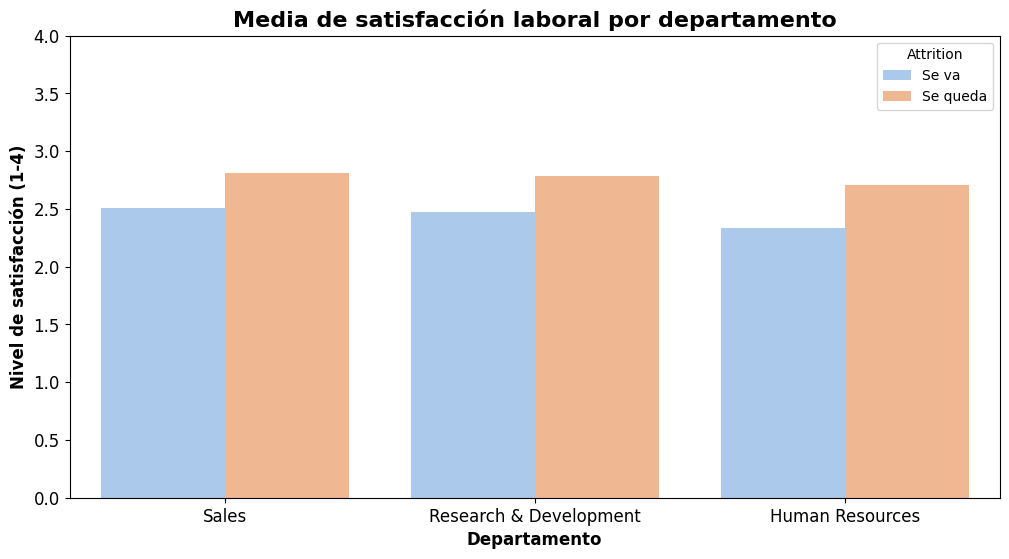

In [68]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_hr_limpios, x='department', y='job_satisfaction', hue='attrition_text',palette='pastel', ci=None,hue_order=['Se va', 'Se queda'])

plt.title('Media de satisfacción laboral por departamento', fontsize=16, fontweight='bold')
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Nivel de satisfacción (1-4)', fontsize=12)
plt.ylim(0, 4)
plt.legend(title='Attrition');

En los tres departamentos, la satisfacción de los empleados que se quedan, presenta niveles de satisfacción consistentemente más altos que los que se van de la empresa. 
Esto confirma que la satisfacción laboran podría ser un indicador predictivo de la fuga de empleados: puntuaciones bajas a 2.5 son un síntoma de riesgo de salida. 
Recomendación: Conviene realizar encuestas de manera periódica para poder identificar bajos niveles de satisfacción entre los departamentos y realizar acciones al respecto (como eventos para el team-building).

## 6. ¿A qué edad se van los empleados?

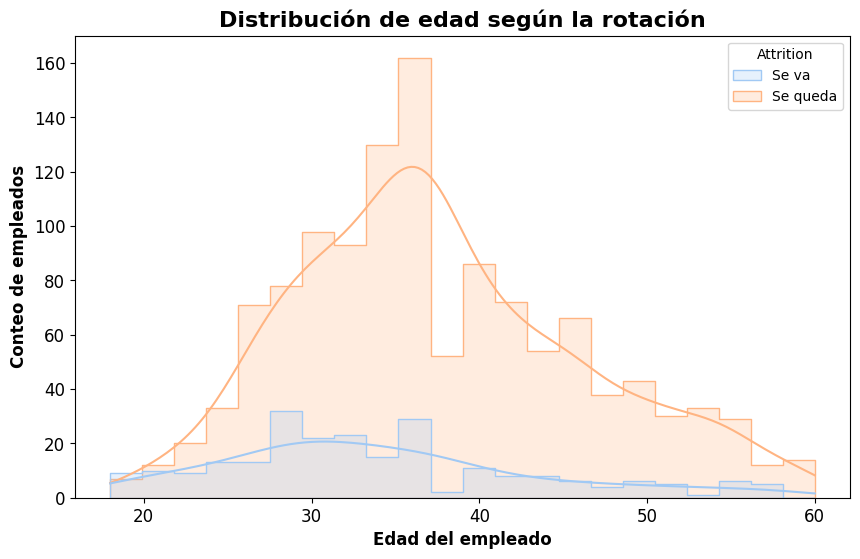

In [69]:
plt.figure(figsize=(10, 6))

ax= sns.histplot(data=df_hr_limpios,x='age',hue='attrition_text',kde=True,palette='pastel',element='step',hue_order=['Se va', 'Se queda'])
plt.title('Distribución de edad según la rotación', fontsize=16, fontweight='bold')
plt.xlabel('Edad del empleado', fontsize=12)
plt.ylabel('Conteo de empleados', fontsize=12)
sns.move_legend(ax, "upper right", title='Attrition');

El análisis demográfico muestra que la rotación se concentra en perfiles más jóvenes (25-35 años). Esto sugiere que ABC Corporation tiene un reto en la fidelización del talento junior, quienes podrían estar buscando mayores oportunidades de crecimiento o cambio de entorno rápidamente.

## 7. ¿Influye la distancia a la oficina?

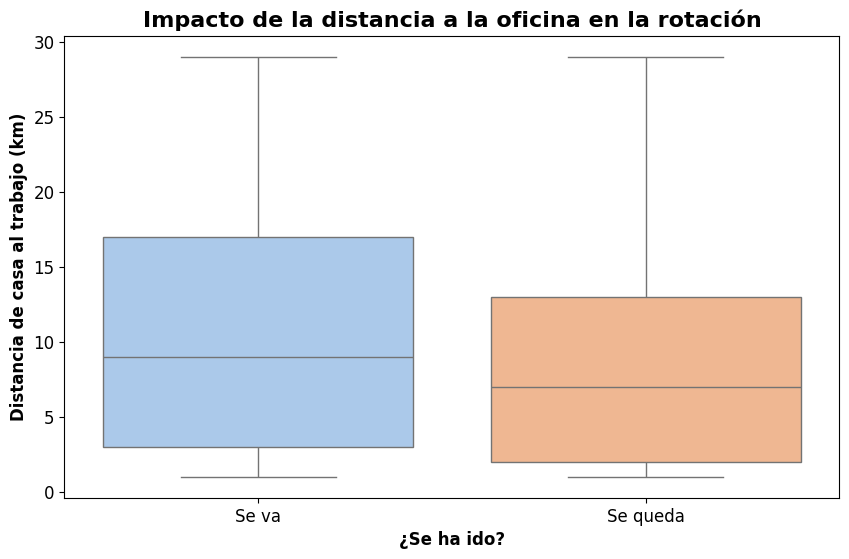

In [60]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_hr_limpios, x='attrition_text', y='distance_from_home', palette='pastel')

plt.title('Impacto de la distancia a la oficina en la rotación', fontsize=16, fontweight='bold')
plt.xlabel('¿Se ha ido?', fontsize=12)
plt.ylabel('Distancia de casa al trabajo (km)', fontsize=12)
plt.show()

Los datos indican que los empleados que viven más lejos tienen una ligera tendencia mayor a abandonar la empresa. Esto abre la puerta a proponer o modificar las políticas de teletrabajo actual como herramienta de retención.

## 8. El impacto del "Burnout" (Horas extra y rotación) 

In [61]:
df_hr_limpios['over_time'].value_counts()

over_time
False    1065
True      405
Name: count, dtype: int64

In [62]:
cross_tab = pd.crosstab(df_hr_limpios['over_time'], df_hr_limpios['attrition_text'], normalize='index') * 100
cross_tab

attrition_text,Se queda,Se va
over_time,,
False,89.483568,10.516432
True,69.135802,30.864198


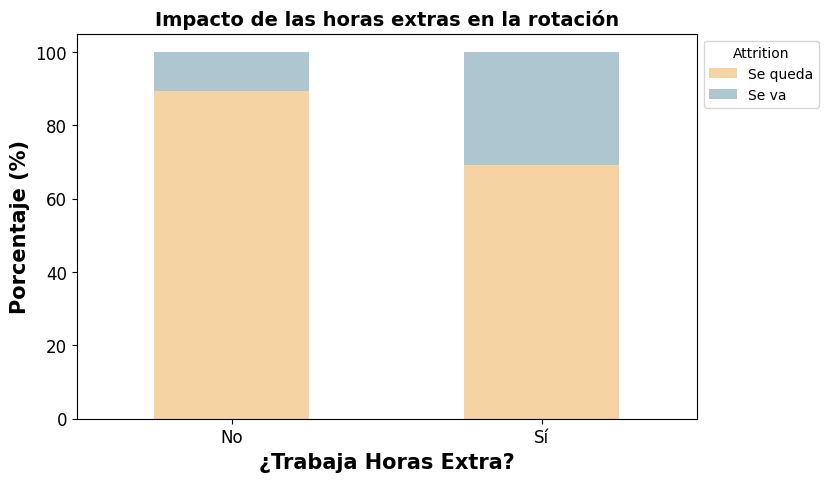

In [70]:
cross_tab = pd.crosstab(df_hr_limpios['over_time'], df_hr_limpios['attrition_text'], normalize='index') * 100
colores_attrition = {'Se va': '#AEC6CF', 'Se queda': "#F5D3A3"}

cross_tab.plot(kind='bar', stacked=True, figsize=(8, 5),color=colores_attrition)

plt.title('Impacto de las horas extras en la rotación', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje (%)')
plt.xlabel('¿Trabaja Horas Extra?')
plt.xticks(ticks=[0,1], labels=["No", "Sí"],rotation=0)
plt.legend(title='Attrition', bbox_to_anchor=(1, 1))
plt.show()

Al observar la relación entre las horas extras (OverTime) y la rotación de personal, la conclusión es contundente: el porcentaje de empleados que abandona ABC Corporation es drásticamente mayor entre quienes realizan horas extras. 
Mientras que el grupo que no realiza horas adicionales presenta una gran estabilidad, el grupo con exceso de jornada muestra una tasa de fuga mucho más alta. Esto sugiere que el agotamiento (burnout) y la falta de equilibrio entre vida personal y laboral son los principales motores de rotación en la compañía.

Los empleados que realizan horas extras tienen una probabilidad de abandonar la empresa significativamente mayor que aquellos con una jornada estándar. 
Recomendación: Implementar políticas de control de jornada y revisar la carga de trabajo en los proyectos más exigentes para frenar la fuga de talento clave.

## 9. Conciliación: Distancia al trabajo y Equilibrio  

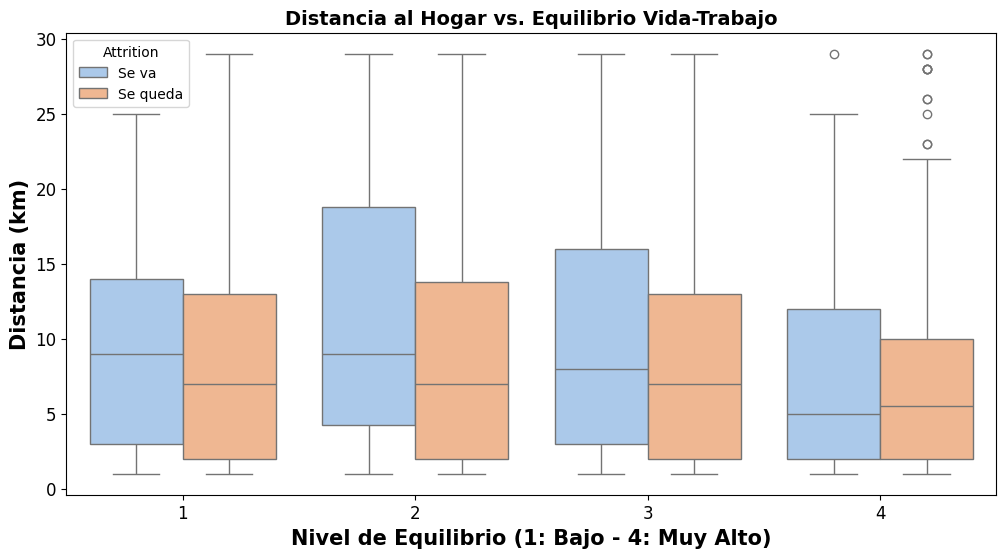

In [71]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_hr_limpios, x='work_life_balance', y='distance_from_home', hue='attrition_text',palette='pastel')

plt.title('Distancia al Hogar vs. Equilibrio Vida-Trabajo', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Equilibrio (1: Bajo - 4: Muy Alto)')
plt.ylabel('Distancia (km)')
plt.legend(title='Attrition')

plt.show()

Se puede observar que las cajas azules suelen ser más altas (los que se van). Esto significa que independientemente de qué tan bueno sea tu equilibrio vida-trabajo, las personas que viven más lejos tienen una mayor tendencia a irse.
La fatiga del desplazamiento parece estar mermando la percepción de calidad de vida de los empleados.

Recomendación: Considerar modelos de trabajo remoto o híbrido específicamente para aquellos empleados cuyo tiempo de desplazamiento sea elevado, mejorando así su satisfacción sin incurrir en costes salariales adicionales.

## 10. ¿Huyen de sus jefes? Liderazgo y Retención 

In [72]:
porcentaje_grupo = pd.crosstab(df_hr_limpios['years_with_curr_manager'],df_hr_limpios['attrition_text'], normalize='index') * 100
porcentaje_grupo

attrition_text,Se queda,Se va
years_with_curr_manager,,
0,69.230769,30.769231
1,86.956522,13.043478
2,86.024845,13.975155
3,83.703704,16.296296
4,89.887640,10.112360
5,86.206897,13.793103
6,88.888889,11.111111
7,84.536082,15.463918
8,89.898990,10.101010


In [73]:
# Preferimos agrupar la columna years_with_curr_manager con diferentes rangos.

In [74]:
def agrupar_años(years_with_curr_manager):
    if years_with_curr_manager <= 1: return '0-1 años'
    elif years_with_curr_manager <= 5: return '2-5 años'
    elif years_with_curr_manager <= 10: return '6-10 años'
    else: 
        return '+10 años'

In [75]:
# Agrupamos por el rango de años con el mismo manager
df_hr_limpios['rango_manager'] = df_hr_limpios['years_with_curr_manager'].apply(agrupar_años)
df_hr_limpios.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition_text,rango_manager
0,41,True,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,8,0,1,6,4,0,5,Se va,2-5 años
1,49,False,Travel_Frequently,Research & Development,8,1,Life Sciences,2,3,Male,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,10,3,3,10,7,1,7,Se queda,6-10 años


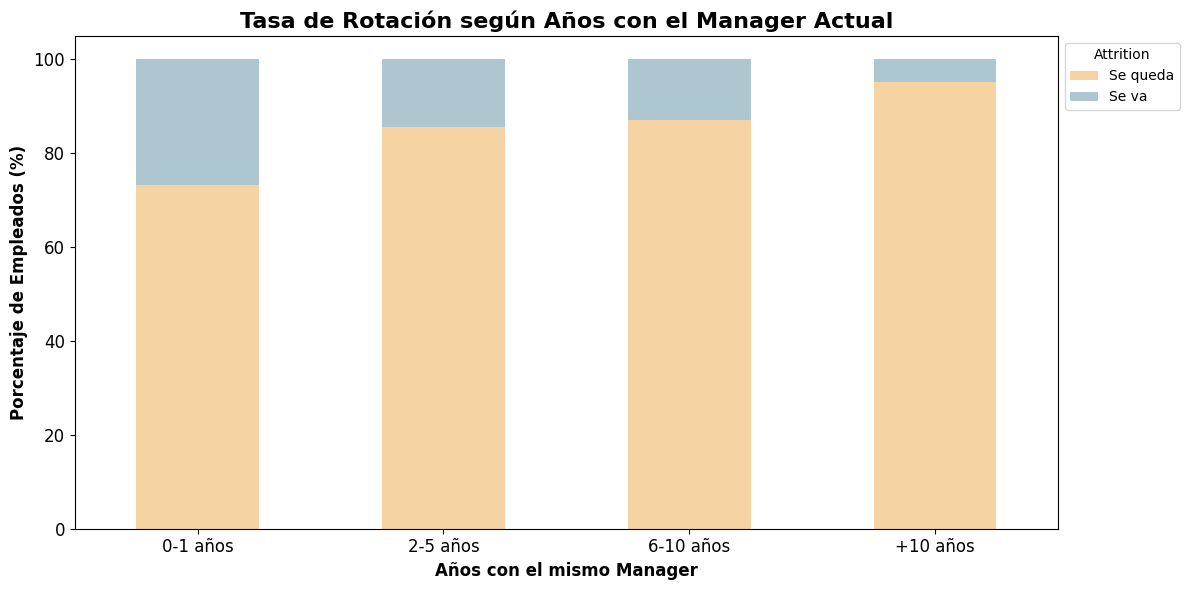

In [76]:
porcentaje_rango = pd.crosstab(df_hr_limpios['rango_manager'], 
                               df_hr_limpios['attrition_text'], 
                               normalize='index') * 100
orden = ['0-1 años', '2-5 años', '6-10 años', '+10 años']
porcentaje_rango = porcentaje_rango.reindex(orden)
ax = porcentaje_rango.plot(kind='bar', stacked=True, figsize=(12, 6),color= ['#F5D3A3','#AEC6CF',]) 

plt.title('Tasa de Rotación según Años con el Manager Actual', fontsize=16, fontweight='bold')
plt.xlabel('Años con el mismo Manager', fontsize=12)
plt.ylabel('Porcentaje de Empleados (%)', fontsize=12)
plt.legend(title='Attrition',bbox_to_anchor=(1, 1))
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

Casi 1 de cada 3 empleados renuncia antes de cumplir los dos años con el nuevo manager. Esto sugiere un problema de adaptación y que la relación empleado-manager durante los primeros meses son un punto débil en la empresa. Una vez que el empleado supera los 2 años con el mismo manager, la probabilidad de que se vaya disminuye. Los managers que logran mantener a su equipo por más de 10 años, tienen una rotación muy reducida. 
Recomendación: mejorar el onboarding o la fase de adaptación entre nuevo manager y empleado. 

## 11. Heatmap de correlación

In [77]:
df_hr_limpios['attrition'].value_counts()

attrition
False    1233
True      237
Name: count, dtype: int64

In [78]:
# Para las correlaciones, creamos una columna nueva "attrition_num" con los valores 0 y 1 (int), para poder usarlos para el análisis de correlación:
df_hr_limpios['attrition_num'] = df_hr_limpios['attrition'].astype(int)
print(df_hr_limpios['attrition_num'].value_counts())

attrition_num
0    1233
1     237
Name: count, dtype: int64


In [79]:
numericas = df_hr_limpios.select_dtypes(include="number")
numericas

matrix = numericas.corr()


In [80]:
numericas

,age,distance_from_home,education,employee_number,environment_satisfaction,job_involvement,job_level,job_satisfaction,monthly_income,monthly_rate,num_companies_worked,percent_salary_hike,performance_rating,relationship_satisfaction,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition_num
0,41,1,2,1,2,3,2,4,5993.0,19479,8,11,3,1,8,0,1,6,4,0,5,1
1,49,8,1,2,3,2,2,2,5130.0,24907,1,23,4,4,10,3,3,10,7,1,7,0
2,37,2,2,4,4,2,1,3,2090.0,2396,6,15,3,2,7,3,3,0,0,0,0,1
3,33,3,4,5,4,3,1,3,2909.0,23159,1,11,3,3,8,3,3,8,7,3,0,0
4,27,2,1,7,1,3,1,2,3468.0,16632,9,12,3,4,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,23,2,2061,3,4,2,4,2571.0,12290,4,17,3,3,17,3,3,5,2,0,3,0
1466,39,6,1,2062,4,2,3,1,9991.0,21457,4,15,3,1,9,5,3,7,7,1,7,0
1467,27,4,3,2064,2,4,2,2,6142.0,5174,1,20,4,2,6,0,3,6,2,0,3,0
1468,49,2,3,2065,4,2,2,2,5390.0,13243,2,14,3,4,17,3,2,9,6,0,8,0


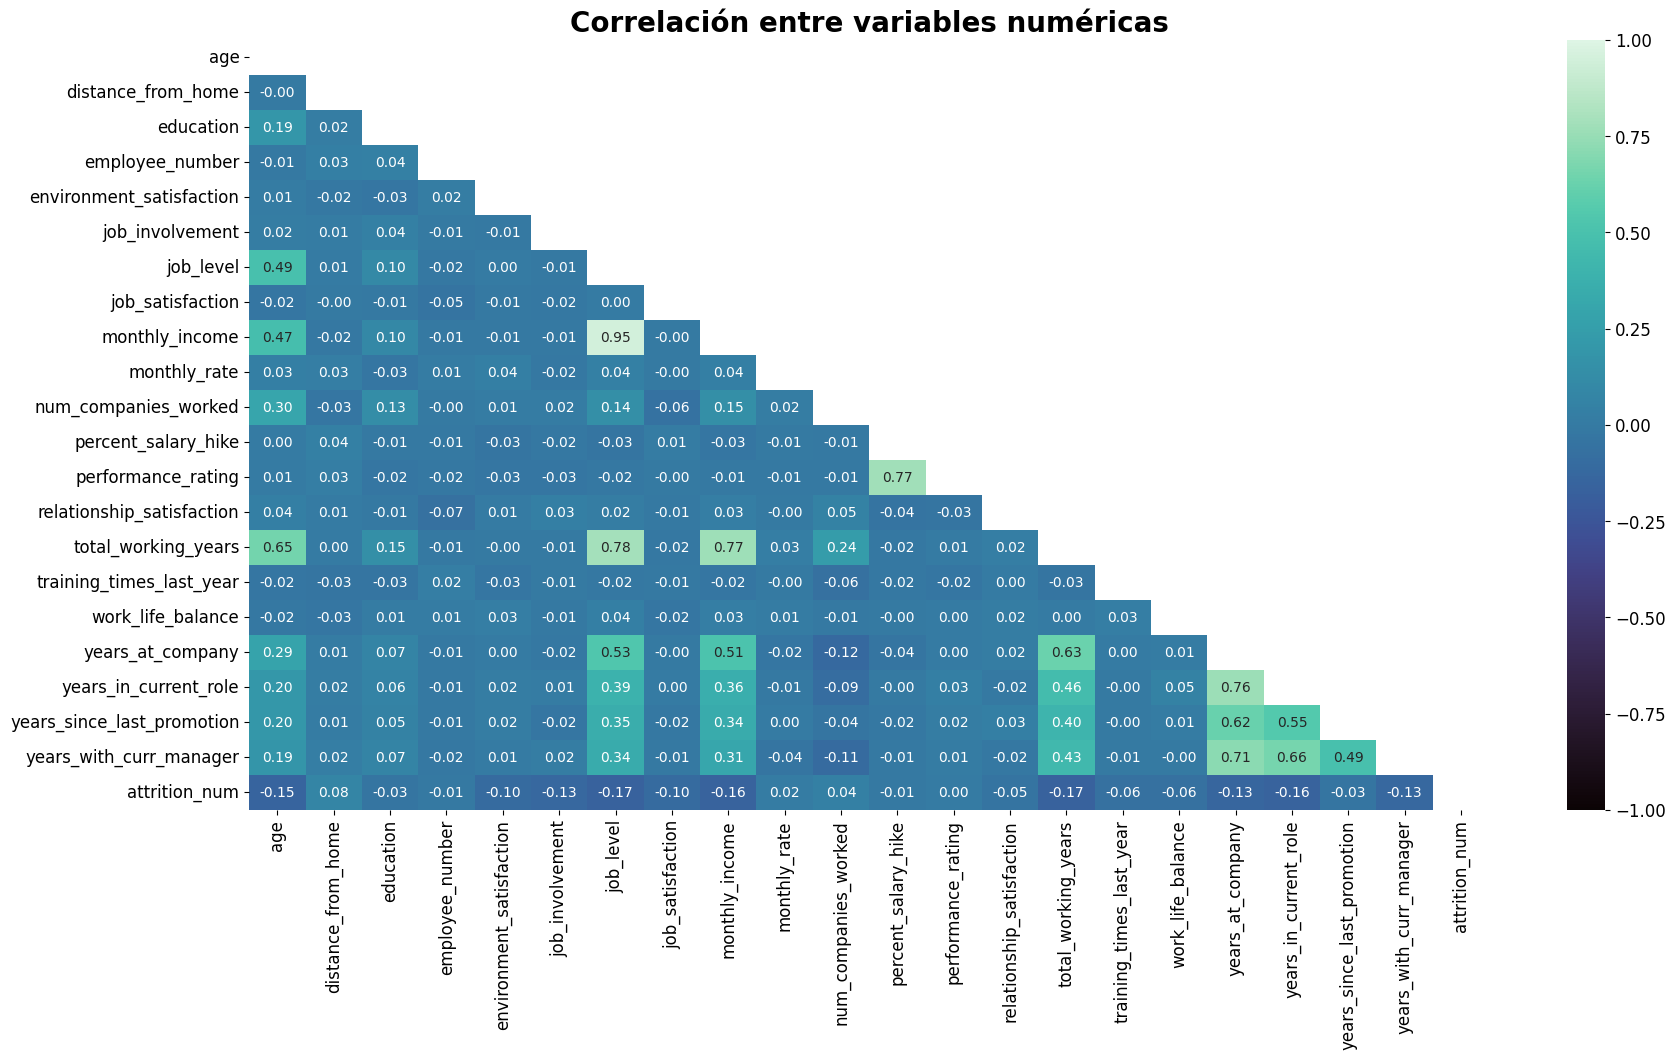

In [81]:
plt.figure(figsize=(20,10)) 
mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, annot=True, fmt='.2f', cmap="mako", vmin=-1, vmax=1,mask=mask)
plt.title("Correlación entre variables numéricas",fontsize=20, fontweight='bold');  

Al analizar la matriz de correlación, observamos que ninguna variable numérica presenta una correlación superior a 0.5 con el attrition. Esto sugiere que la decisión de abandonar la empresa no depende de un único factor crítico aislado, sino que es un fenómeno complejo derivado de la acumulación de varios factores (más abajo).
Esto se confirma al hacer una heatmap solo con attrition y las otras variables.

Hay un grupo de variables que tienen alta correlación entre ellas: 
* Monthly income y job level (0.95): Esta es la correlación más alta. A mayor rango jerárquico, mayor sueldo (tiene lógica).
* Performance rating y percent salary hike (0.77): El aumento salarial está directamente ligado al desempeño evaluado. 
* Total working years con job level (0.78) e income (0.77): La veteranía en el mercado laboral es el principal motor del ascenso y del salario. 
Insights sobre el ciclo de vida en la empresa:
* Years at company y years with current manager (0.71): Inidica que hay una tendencia a mantener los mismos equipos de trabajo durante mucho tiempo. 
* Years at company y years in current Role (0.76): Los empleados tienden a quedarse en el mismo puesto a medida que pasan los años en la empresa, aunque la relación con las promociones es algo menor (0.62).
Insights sobre la edad: 
* Total working years y age (0.65): Esperable, pero no perfecta (hay gente que empieza a trabajar tarde o cambia de carrera).
* Monthly income y age (0.47): Esto sugiere que en esta empresa el job level (viso antes, 0.95) importa mucho más que la edad para determinar cuánto gana alguien.

Mediante este mapa de calor, hemos identificado las palancas que realmente mueven los indicadores de ABC Corporation. Destaca la fuerte relación entre el job level y el salario, pero también observamos que la satisfacción laboral no siempre está ligada al nivel económico, lo que sugiere que factores como el equilibrio vida-trabajo y la relación con los managers (vistos en gráficos anteriores) tienen un peso propio e independiente en la moral del equipo.


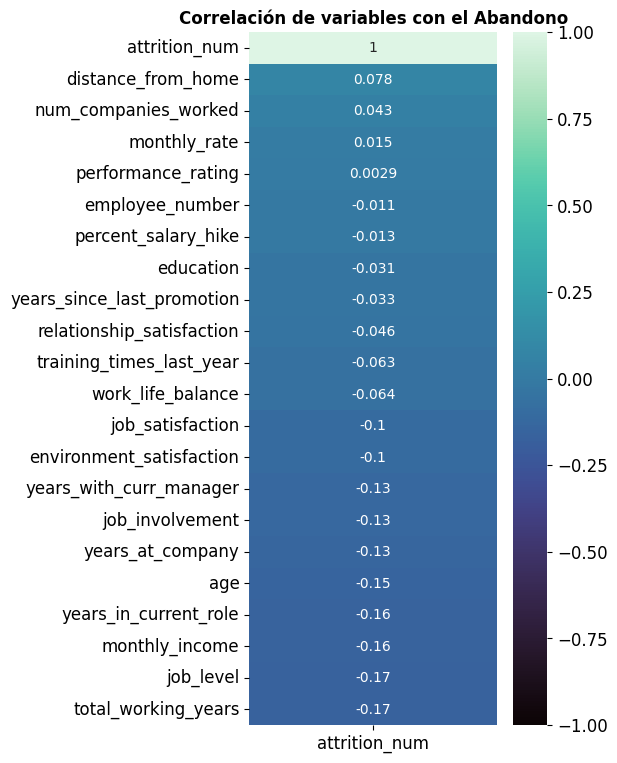

In [82]:
# Heatmap solo con attrition y las otras variables:
plt.figure(figsize=(4, 9))
sns.heatmap(numericas.corr()[['attrition_num']].sort_values(by='attrition_num', ascending=False),annot=True, cmap='mako', vmin=-1, vmax=1)
plt.title('Correlación de variables con el Abandono',fontsize=12, fontweight='bold'); 

## 12. Relación del abandono con aumentos salariales:

In [83]:
def agrupar_salary_hike (percent_salary_hike):
    if percent_salary_hike <= 14: return 'Bajo (11-14%)'
    elif percent_salary_hike <= 18: return 'Medio (15-18%)'
    elif percent_salary_hike <= 21: return 'Alto (19-21%)'
    else:
        return 'Muy Alto (+22%)'

In [84]:
df_hr_limpios['hike_rango'] = df_hr_limpios['percent_salary_hike'].apply(agrupar_salary_hike)
df_hr_limpios.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition_text,rango_manager,attrition_num,hike_rango
0,41,True,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,8,0,1,6,4,0,5,Se va,2-5 años,1,Bajo (11-14%)
1,49,False,Travel_Frequently,Research & Development,8,1,Life Sciences,2,3,Male,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,10,3,3,10,7,1,7,Se queda,6-10 años,0,Muy Alto (+22%)


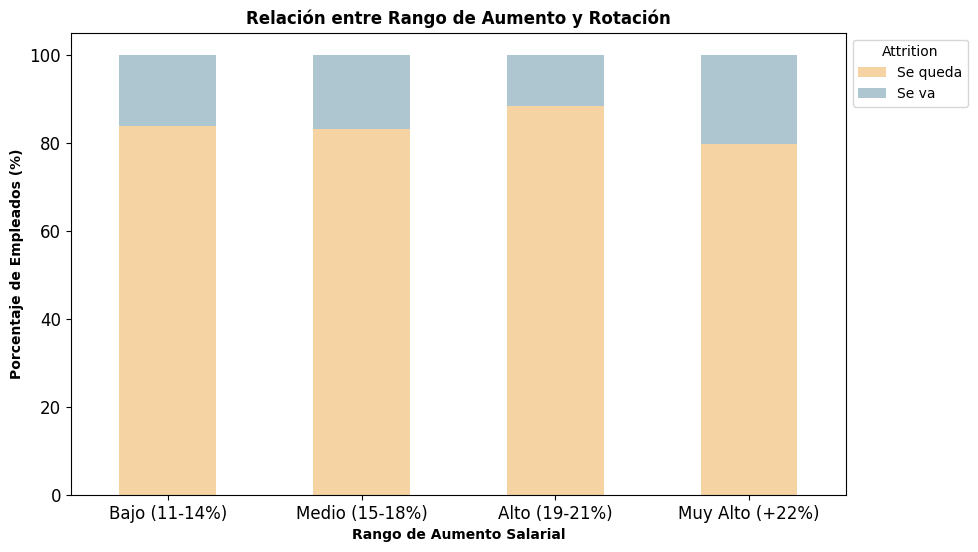

In [86]:
orden = ['Bajo (11-14%)', 'Medio (15-18%)', 'Alto (19-21%)', 'Muy Alto (+22%)']
cross_tab = pd.crosstab(df_hr_limpios['hike_rango'], df_hr_limpios['attrition_text'], normalize='index') * 100
cross_tab = cross_tab.reindex(orden) 

colores = {'Se va': '#AEC6CF', 'Se queda': '#F5D3A3'}
cross_tab.plot(kind='bar', stacked=True, color=colores, figsize=(10, 6))

plt.title('Relación entre Rango de Aumento y Rotación',fontsize=12)
plt.ylabel('Porcentaje de Empleados (%)',fontsize=10)
plt.xlabel('Rango de Aumento Salarial',fontsize=10)
plt.legend(title='Attrition', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0);

Sorprendentemente, la barra de muy alto muestra la mayor tasa de abandono (alrededor de un 20%). Dar aumentos masivos no garantiza la retención de talento. Probablemente a estos empleados se les dé un aumento muy fuerto como contraoferta cuando ya están pensando en irse o porque sean perfiles profesionales muy fuertes con una demanda alta que ni un aumento salarial tan importante logra retenerlos. 
El salto de calidad en retención solo se nota cuando se llega al 19%. Si la empresa está ajustando presupuestos, subir un aumento del 12% al 15% no tendrá garn impacto en la retención.

En resumen, el aumento porcentual es un factor que influye, pero no es el motivo principal de fuga (la gran mayoría de los trabajadores se queda independientemente del rango de aumento). El abandono está bastante repartido, lo que sugiere que hay otros problemas de fondo.

## 13. Relación del abandono con frecuencia de viajes de trabajo:


In [89]:
tab_viajes

attrition_text,Se queda,Se va
business_travel,,
Non_Travel,91.366906,8.633094
Travel_Rarely,85.018727,14.981273
Travel_Frequently,75.285171,24.714829


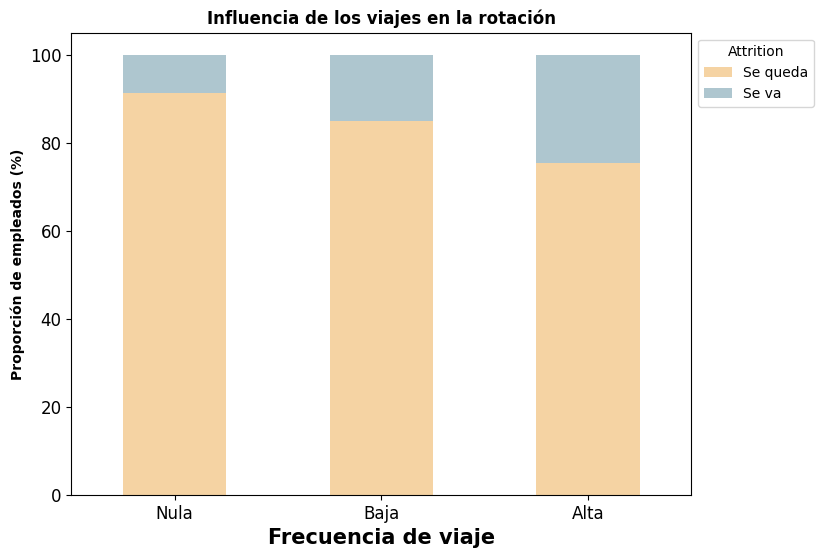

In [91]:
# Creamos la tabla cruzada normalizada (cada fila suma 100%)
tab_viajes = pd.crosstab(df_hr_limpios['business_travel'], 
                         df_hr_limpios['attrition_text'], 
                         normalize='index') * 100

orden = ['Non_Travel', 'Travel_Rarely', 'Travel_Frequently']
tab_viajes = tab_viajes.reindex(orden)

colores = {'Se va': '#AEC6CF', 'Se queda': '#F5D3A3'}
ax = tab_viajes.plot(kind='bar', stacked=True, color=colores, figsize=(8, 6))

plt.title('Influencia de los viajes en la rotación',fontsize=12)
plt.ylabel('Proporción de empleados (%)',fontsize=10)
plt.xlabel('Frecuencia de viaje')
plt.xticks(ticks=[0,1,2], labels=["Nula", "Baja","Alta"],rotation=0)

plt.legend(title='Attrition', bbox_to_anchor=(1, 1))
plt.show()

Existe una relación lineal clara: a mayor frecuencia de viajes, mayor es la proporción de empleados que deciden irse (Se Va, franja azul).
* Non_Travel (No viajan): Tienen la tasa de fuga más baja, aproximadamente un 10%. Es el grupo más estable.
* Travel_Rarely (Viajan raramente): La fuga sube a un nivel intermedio, cerca del 15%.
* Travel_Frequently (Viajan frecuentemente): La fuga se dispara hasta casi un 25%.

Un empleado que viaja frecuentemente tiene casi 3 veces más probabilidades de abandonar la empresa que uno que no viaja nunca. Recursos humanos debería revisar las políticas de compensación o descanso para los empleados que viajan frecuentamente, ya que están perdiendo 1 de cada 4 empleados en esa categoría.

## 14. Influencia de las formaciones recibidas según rotación

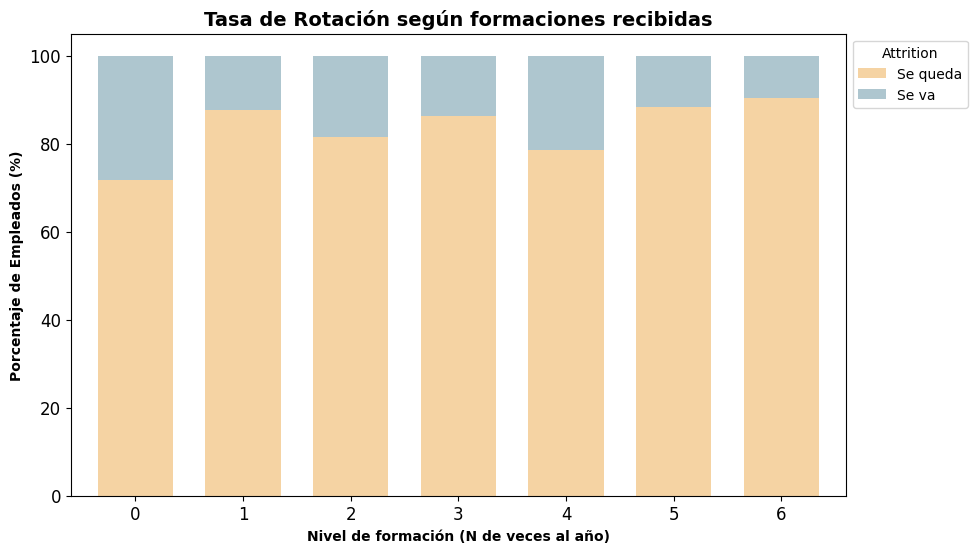

In [88]:
tab_formacion = pd.crosstab(df_hr_limpios['training_times_last_year'],df_hr_limpios['attrition_text'], normalize='index') * 100

colores_attrition = {'Se va': '#AEC6CF', 'Se queda': '#F5D3A3'}

ax = tab_formacion.plot(kind='bar', stacked=True, color=colores_attrition, figsize=(10, 6),width=0.7)

plt.title('Tasa de Rotación según formaciones recibidas', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje de Empleados (%)',fontsize=10)
plt.xlabel('Nivel de formación (N de veces al año)',fontsize=10)
plt.xticks(rotation=0)
plt.legend(title='Attrition', bbox_to_anchor=(1, 1))
plt.show()

No existe una relación perfecta, pero sí algo claro: la formación es un escudo contra la rotación. Alrededor de un 30% de los empleados que no recibde ninguna formación durante el primer añ0, se va de la empresa. Pasar de 0 a 1 formaciones anuales reduce el riesgo de fuga. El punto óptimo de inversión para mantener la estabilidad parece estar entre 1 y 3 formaciones anuales.